# Michael_NRE

In [587]:
import justNRE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score
from importlib import reload

from tqdm import tqdm
reload(justNRE)

<module 'justNRE' from '/home/ntriantafyllou/projects/Michael NRE/justNRE.py'>

## Specify data

In [951]:
# Data and parameters into the format of concatenate[summary, xHI] shape: (number_of_sims, number of observables + parameters)
# Load data 
data_params1 = np.load('acf_NRE.npy')
data_params2 = np.load('betti_NRE_v3.npy')

data_params = np.concatenate((data_params1[:,:-1], data_params2), axis=1)

In [937]:
def generate_mock_dataset(num_simulations=4000, num_features=2, seed=42):
    rng = np.random.default_rng(seed)
    # Simulate the raw physical parameters (chi) matching a grid of 0.2 and 0.25
    params = np.random.uniform(0.05, 0.45, size=(num_simulations, 1))
    # Simulate observables that depend directly on chi + some physical noise
    data = (params * 4.0) + rng.normal(0, 0.001, size=(num_simulations, num_features))
    data_params = np.hstack([data, params])
    return data_params

# Or use mock data
data_params = generate_mock_dataset()

In [952]:
param_dim = 1
number_of_sims = data_params.shape[0] ; print('You are using', number_of_sims, 'simulations')

You are using 18000 simulations


## Train an ML algorithm

In [953]:
data_arr   = data_params[:,:-1]
params_arr = data_params[:, -1:]

instances, targets = justNRE.prepare_for_NRE(data_arr, params_arr)
# alternatively check with mock data
# instances, targets = generate_mock_nre_dataset()

(X_train, y_train), (X_val, y_val), (X_test, y_test) = justNRE.split(instances, targets, [80, 10, 10])

(X_train_norm, X_val_norm, X_test_norm), denormalize, normalize = justNRE.normalize((X_train, X_val, X_test), norm_type='standard')


number_of_simulations: 18000
Half that is reserved for independetly drawn samples: 9000.0
Same but integer: 9000.0


In [954]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K

def build_smooth_mlp(input_dim, L2_reg=1e-3):
    """Pure function to compile a highly regularized, smooth MLP."""
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation='swish', kernel_regularizer=tf.keras.regularizers.l2(L2_reg)),
        BatchNormalization(),
        Dropout(0.3),  # High dropout pushes the model to default to 0.5 if features are noise
        Dense(32, activation='swish', kernel_regularizer=tf.keras.regularizers.l2(L2_reg)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=1e-3))
    return model

def train_nre_ensemble(X_tr, y_tr, X_va, y_va, num_models=5, base_seed=42):
    """
    Trains an ensemble of independent models.
    Returns: A list of trained Keras models.
    """
    ensemble = []
    
    for i in range(num_models):
        print(f"\n--- Training Ensemble Member {i+1}/{num_models} ---")
        K.clear_session()
        
        # Set unique seed per member for diverse initialization and shuffling
        tf.random.set_seed(base_seed + i)
        np.random.seed(base_seed + i)
        
        # Build and fit
        model = build_smooth_mlp(input_dim=X_tr.shape[1])
        model.fit(
            X_tr, y_tr, 
            epochs=150, 
            validation_data=(X_va, y_va), 
            batch_size=128, 
            verbose=0  # Silent training to keep notebook clean
        )
        ensemble.append(model)
        
    return ensemble

# Train your ensemble (e.g., 5 models)
nre_ensemble = train_nre_ensemble(X_train_norm, y_train, X_val_norm, y_val, num_models=5)


--- Training Ensemble Member 1/5 ---

--- Training Ensemble Member 2/5 ---

--- Training Ensemble Member 3/5 ---

--- Training Ensemble Member 4/5 ---

--- Training Ensemble Member 5/5 ---


In [1007]:
def ensemble_predict(nre_ensemble, X_test):
    X_test_norm = normalize(X_test)
    # Convert input explicitly to a standard NumPy array to kill internal TF tracing bugs
    if hasattr(X_test_norm, "values"):  # If it's a Pandas DataFrame/Series
        X_test_norm = X_test_norm.values
    X_clean = np.asarray(X_test_norm, dtype=np.float32)
    
    all_preds = []
    for model in nre_ensemble:
        # Pass the clean array directly
        preds = model.predict(X_clean, verbose=0).flatten()
        all_preds.append(preds)
        
    return np.mean(all_preds, axis=0)
#     return all_preds[4]

In [1008]:
# Predict
y_proba = ensemble_predict(nre_ensemble, X_test)
# y_proba = model.predict_proba(X_test_norm)[:, 1]  # for AUC or sigmoid-like scores

# print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

ROC AUC: 0.6217583479452495


In [1009]:
def log_ratio(obs, theta, model=model): 
    """Figure it out
    Likelihood to evidence ratio (in log)"""
    X_something = np.concatenate((obs,theta), axis=0)
    
    X_something =X_something.reshape(1,-1)
#     X_something_norm = normalize(X_something)
    y_proba = ensemble_predict(nre_ensemble, X_something)
#     print(y_pred)
    # Avoid division by zero or log(0)
    eps = 1e-16
    y_proba = np.clip(y_proba, eps, 1 - eps)
    logr = np.log(y_proba) -np.log((1 - y_proba))
    return logr

In [1010]:
def log_ratio_vectorized(obs, theta_array, model=model): 
    obs = obs.reshape(1,-1)
    obs_array = np.repeat(obs, len(theta_array), axis=0)

    theta_array = theta_array.reshape(-1,1)
    X_something = np.concatenate((obs_array, theta_array), axis=1)
    y_proba = ensemble_predict(nre_ensemble, X_something)
    eps = 1e-16
    y_proba = np.clip(y_proba, eps, 1 - eps)
    logr = np.log(y_proba) -np.log((1 - y_proba))
    return logr

In [1011]:
# justNRE.plot_confusion_matrix(X_val_norm, y_val, model)

### Plot a likelihood/posterior

You chose a neural fraction of [0.25]


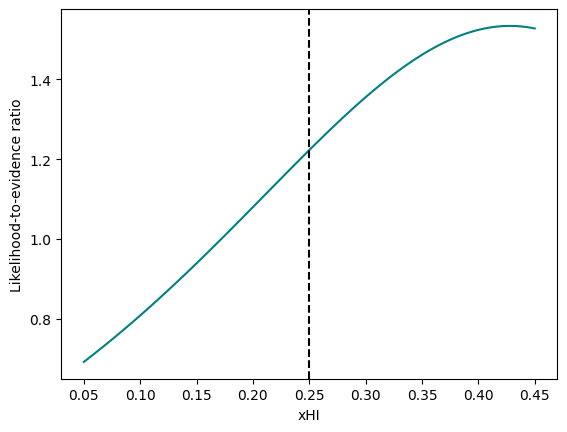

You chose a neural fraction of [0.05]


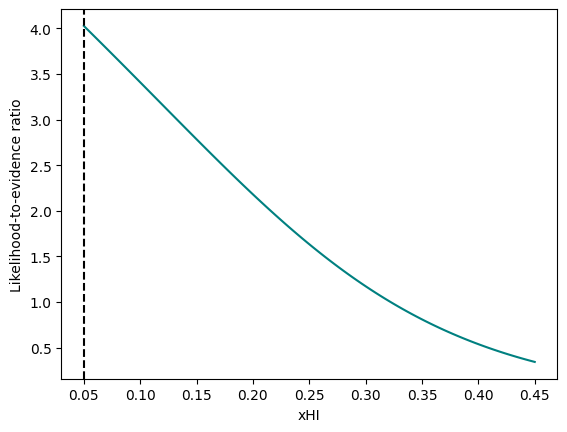

You chose a neural fraction of [0.3]


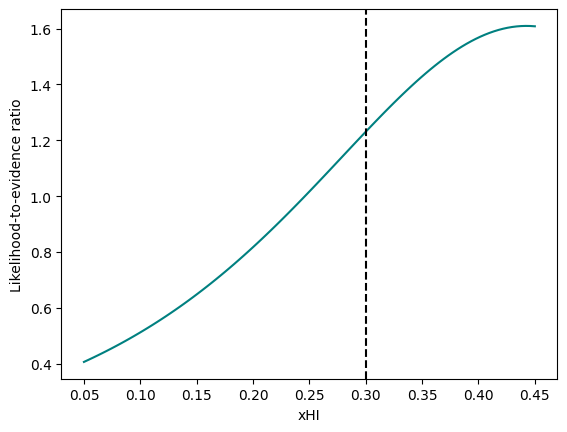

You chose a neural fraction of [0.3]


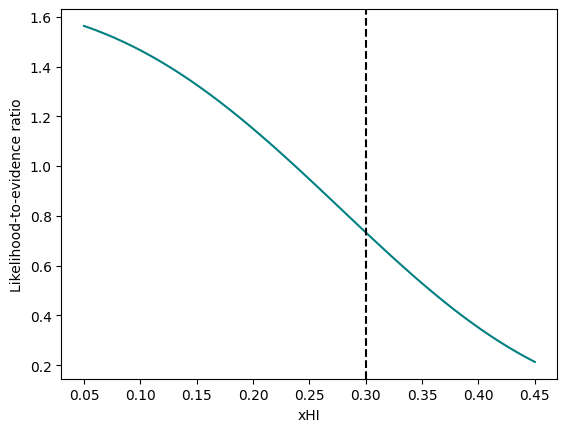

You chose a neural fraction of [0.35]


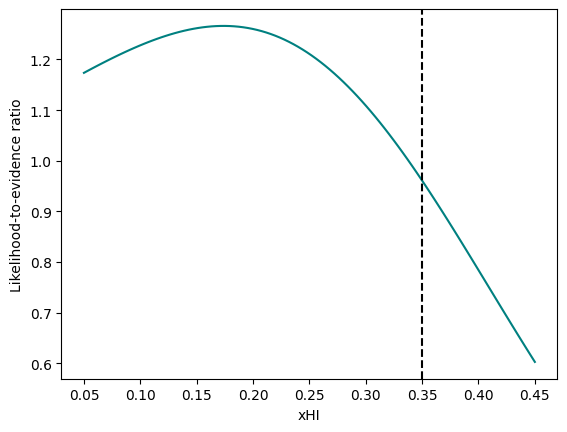

You chose a neural fraction of [0.1]


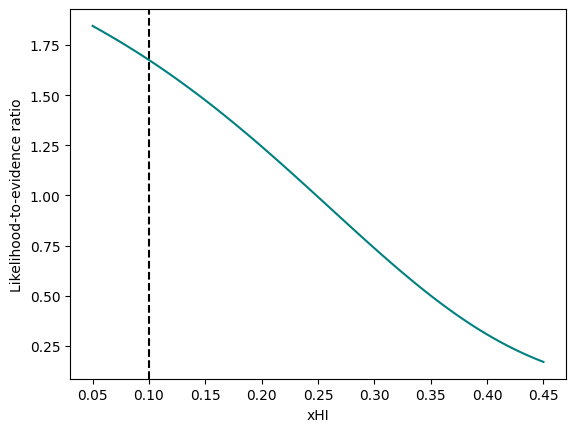

You chose a neural fraction of [0.05]


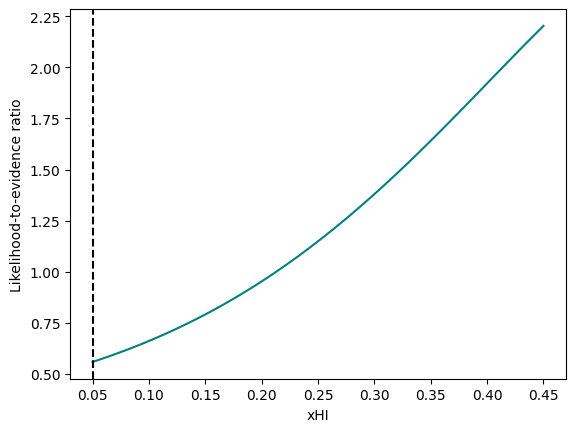

You chose a neural fraction of [0.2]


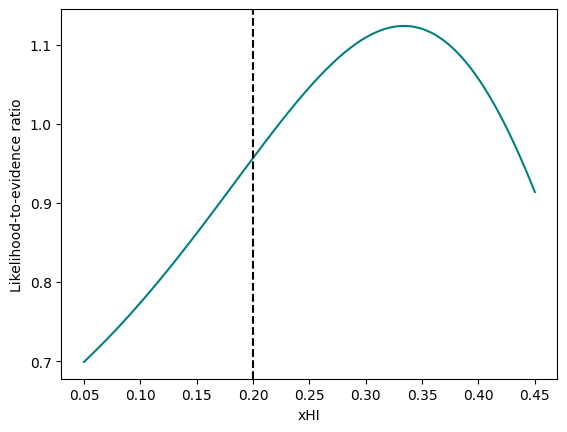

You chose a neural fraction of [0.4]


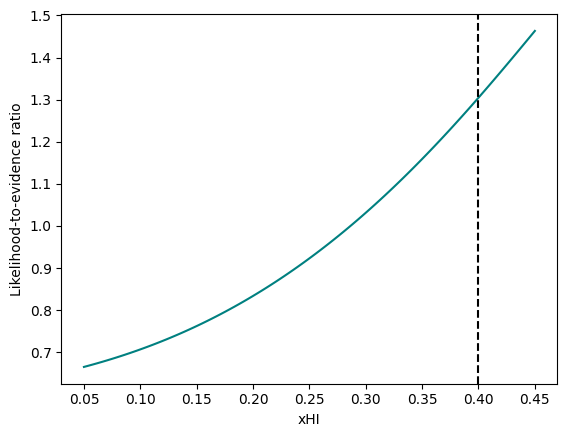

You chose a neural fraction of [0.35]


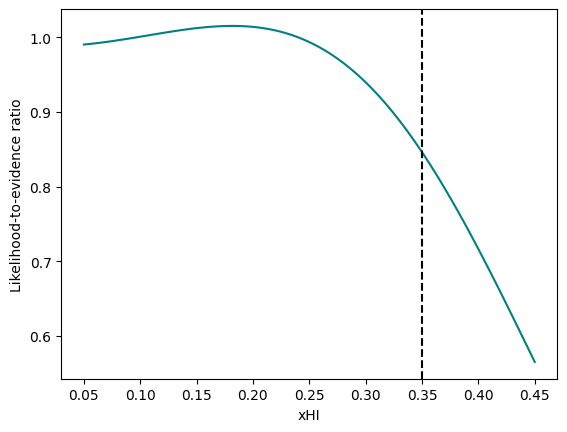

You chose a neural fraction of [0.45]


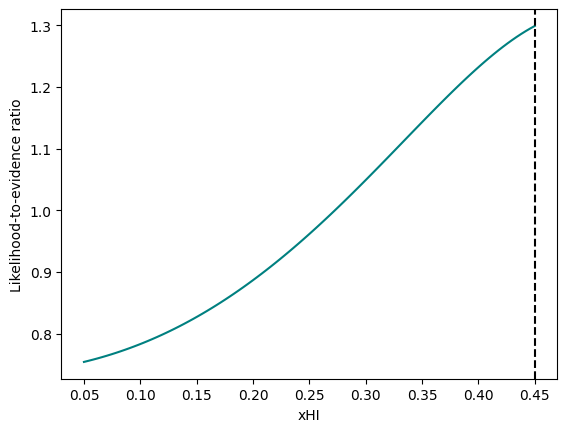

You chose a neural fraction of [0.1]


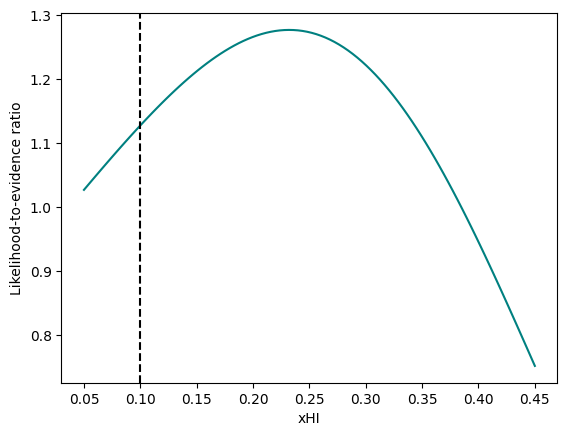

You chose a neural fraction of [0.45]


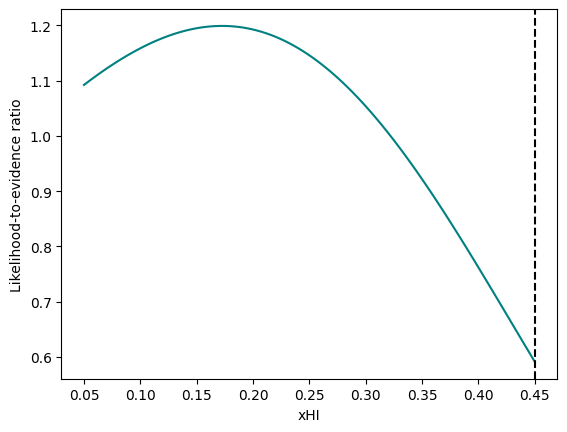

You chose a neural fraction of [0.05]


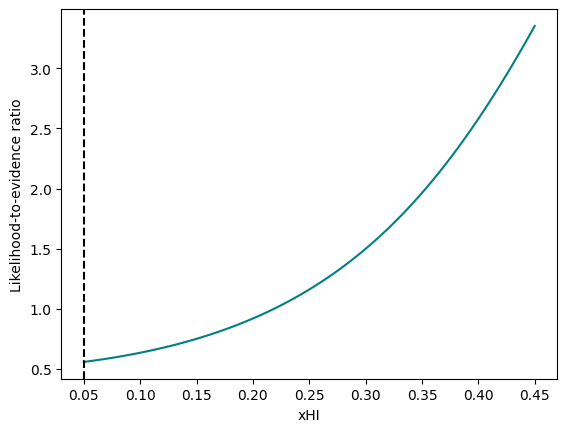

You chose a neural fraction of [0.05]


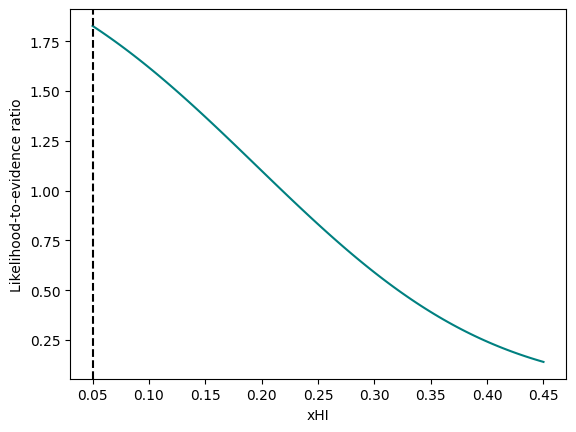

You chose a neural fraction of [0.4]


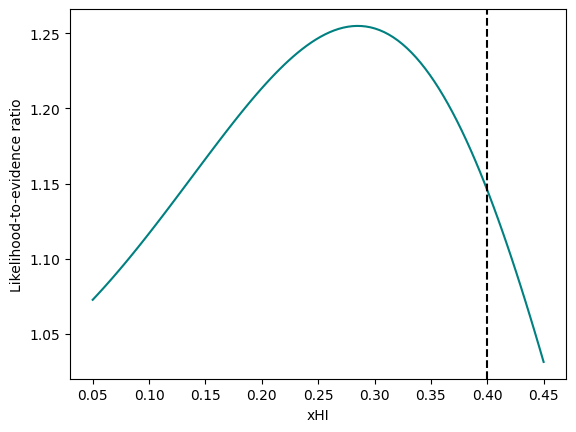

You chose a neural fraction of [0.15]


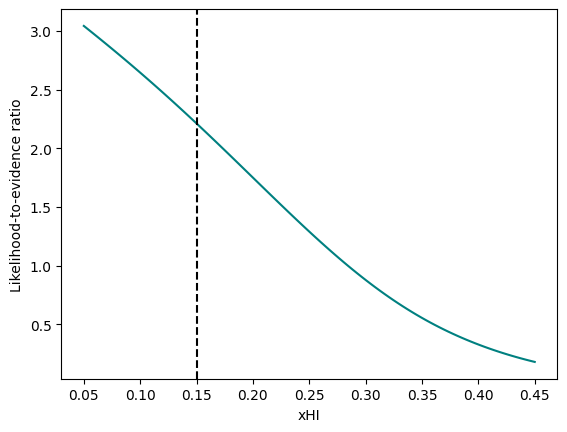

You chose a neural fraction of [0.2]


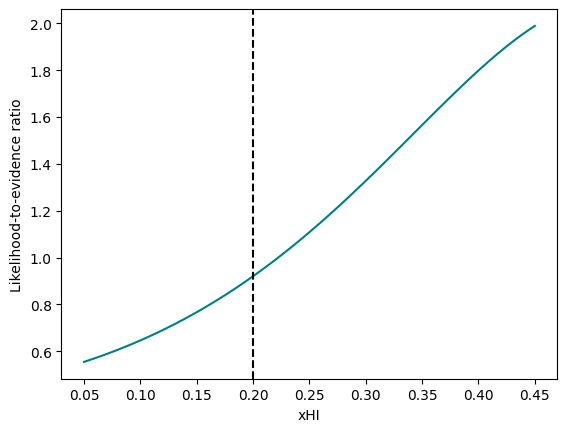

You chose a neural fraction of [0.15]


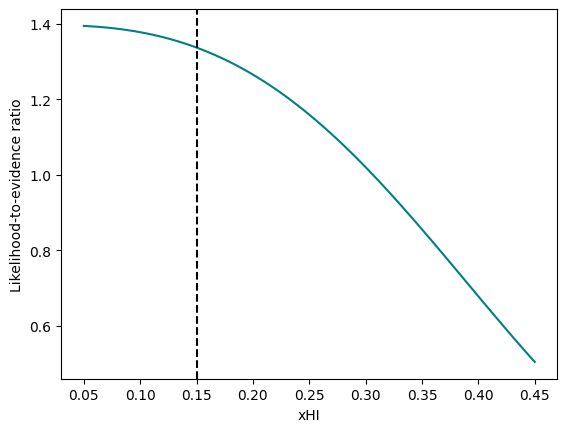

You chose a neural fraction of [0.45]


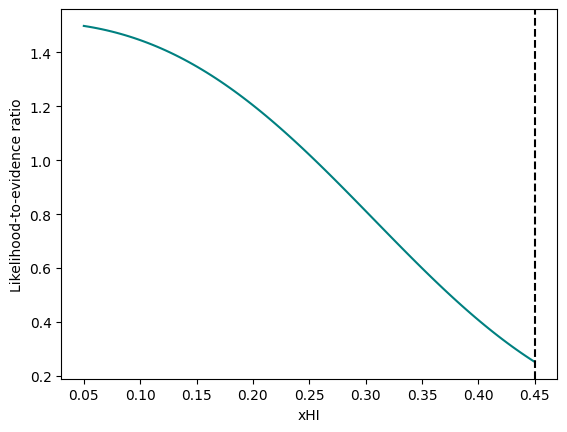

In [1012]:
# Pick an observation from the test set
# Choose one
which_one = 84

for which_one in range(20):
    # num_of_observation = 514-9
    obs_true = np.array(X_test[which_one, :-1] )
    theta_true = np.array(X_test[which_one, -1:] )

    print('You chose a neural fraction of', theta_true)

    xhi_arr = np.linspace(0.05, 0.45, 100)
    log_ratios_list = log_ratio_vectorized(obs_true, xhi_arr)

    plt.plot(xhi_arr, np.exp(log_ratios_list), color='teal')
    plt.axvline(theta_true, color='black', linestyle='--')
    plt.xlabel('xHI')
    plt.ylabel('Likelihood-to-evidence ratio')
    plt.show()

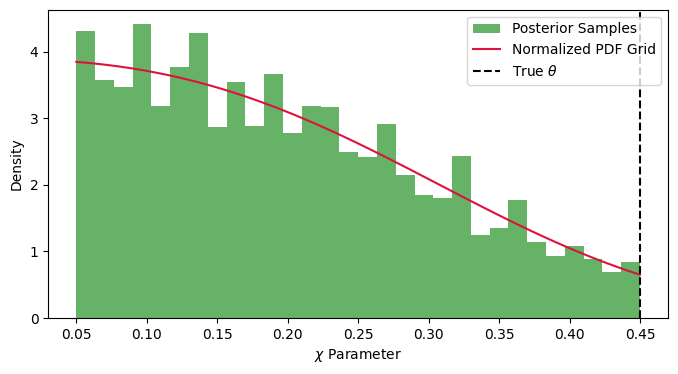

In [1013]:
import numpy as np

# 1. Convert log-ratios back to unnormalized likelihood ratios
unnormalized_likelihood = np.exp(log_ratios_list)
# 2. Convert the continuous likelihood into discrete bin probabilities
# (Dividing by the sum ensures all probabilities add up to exactly 1.0)
bin_probabilities = unnormalized_likelihood / np.sum(unnormalized_likelihood); bin_probabilities = bin_probabilities.flatten()
# 3. Draw random samples from your xhi_arr based on those probabilities
num_samples = 5000  # Choose how many samples you want
posterior_samples = np.random.choice(xhi_arr, size=num_samples, p=bin_probabilities)

# --- Verify by plotting a histogram of your new samples ---
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.hist(posterior_samples, bins=30, density=True, alpha=0.6, color='g', label='Posterior Samples')
plt.plot(xhi_arr, unnormalized_likelihood / np.sum(unnormalized_likelihood * (xhi_arr[1]-xhi_arr[0])), 
         color='crimson', label='Normalized PDF Grid')
plt.axvline(theta_true, color='black', linestyle='--', label='True $\\theta$')
plt.xlabel('$\\chi$ Parameter')
plt.ylabel('Density')
plt.legend()
plt.show()

In [1014]:
posterior_samples.std()

0.10242335488946645

# IGNORE

In [471]:
supersamples = []
for which_one in range (400):
#     which_one = 41
    # num_of_observation = 514-9
    obs_true = np.array(X_test[which_one, :-1] )
    theta_true = np.array(X_test[which_one, -1:] )


    xhi_arr = np.linspace(0.05, 0.45, 300)
    log_ratios_list = []
    for i in range(len(xhi_arr)):
        log_ratios_list.append(log_ratio(obs_true, [xhi_arr[i]]))
    
    # 1. Convert log-ratios back to unnormalized likelihood ratios
    unnormalized_likelihood = np.exp(log_ratios_list)
    # 2. Convert the continuous likelihood into discrete bin probabilities
    # (Dividing by the sum ensures all probabilities add up to exactly 1.0)
    bin_probabilities = unnormalized_likelihood / np.sum(unnormalized_likelihood); bin_probabilities = bin_probabilities.flatten()
    # 3. Draw random samples from your xhi_arr based on those probabilities
    num_samples = 5000  # Choose how many samples you want
    supersamples.append(np.random.choice(xhi_arr, size=num_samples, p=bin_probabilities))
    
    
supersamples = np.array(supersamples).T[:,:,np.newaxis] # (number of samples, number of simulations, number of parameters)

In [468]:
supertrue = X_test[:,-param_dim:]    # (number of simulations, number of parameters)

In [470]:
supertrue.shape

(400, 1)

In [ ]:

# Compute the ranks
rank_dict = {}
for parameter_name in param_names: rank_dict[f'{parameter_name}']=[]

for parameter_id in range(10):
    for theta_true, posterior_samples in zip(theta_true_list, posterior_samples_list):
        rank = np.sum(posterior_samples[:,parameter_id] < theta_true[parameter_id])
        rank_dict[param_names[parameter_id]].append(rank)

In [441]:
 X_test[:,-param_dim:]    .shape
    

(400, 1)